In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Data

In [2]:
from scipy.io import loadmat
data = loadmat('../data/mnist_train_test.mat',
               squeeze_me=True, struct_as_record=False)
train, test = data['train'], data['test']

print(train._fieldnames)

for name in train._fieldnames:
    val = getattr(train, name)
    print(name, type(val), getattr(val, 'shape', None), getattr(val, 'dtype', None))

X = train.X.T
y = train.y.astype(np.float64)
d = X.shape[1]       

['X', 'y']
X <class 'numpy.ndarray'> (785, 12665) float64
y <class 'numpy.ndarray'> (12665,) uint8


# Q2

In [3]:
def loss_loop(y, X, theta):
    total = 0
    for i in range(len(y)):
        s_i = 1 - 2 * y[i]
        z_i = s_i * np.dot(X[i], theta)

        if z_i >= 0:
            total += 0.5 + z_i
        elif z_i >= -1:
            total += 0.5 * (1 + z_i) ** 2

    return total

def loss_vectorized(y, X, theta):
    z = (1 - 2 * y) * (X @ theta)
    return np.sum(np.where(z >= 0, 0.5 + z,
                  np.where(z >= -1, 0.5 * (1 + z) ** 2, 0.0)))

def loss_regularized(y, X, theta, lambda_const):
    data_loss = loss_vectorized(y, X, theta)
    return data_loss + (lambda_const / 2) * np.dot(theta, theta)

In [4]:
def grad_loop(y, X, theta):
    grad = np.zeros(len(theta))
    for i in range(len(y)):
        s_i = 1 - 2 * y[i]
        z_i = s_i * np.dot(X[i], theta)

        phi_prime = 0
        if z_i >= 0:
            phi_prime = 1
        elif z_i >= -1:
            phi_prime = 1 + z_i

        grad += s_i * phi_prime * X[i]

    return grad


def grad_vectorized(y, X, theta):
    s = 1 - 2 * y
    z = s * (X @ theta)
    weights = s * np.where(z >= 0, 1, np.where(z >= -1, 1 + z, 0))
    return X.T @ weights


def grad_regularized(y, X, theta, lambda_const):
    return grad_vectorized(y, X, theta) + lambda_const * theta

# Q3

In [5]:
t = np.logspace(-8.0, 0.0, num = 101)
lambda_const = 0.005

rng = np.random.default_rng(0)
theta = rng.standard_normal(d)

v = rng.standard_normal(d)
v /= np.linalg.norm(v)

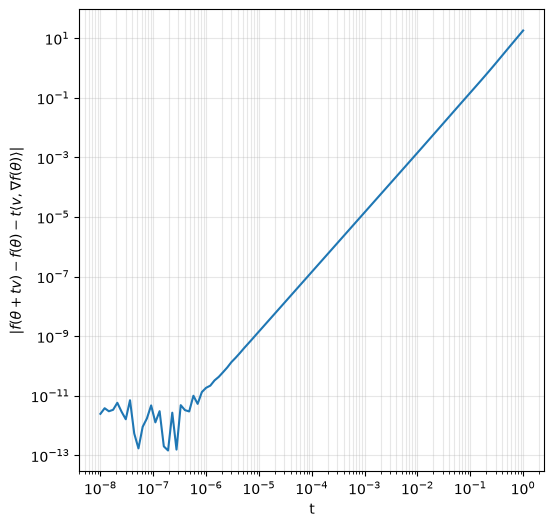

In [6]:
f0 = loss_regularized(y, X, theta, lambda_const)
g0 = grad_regularized(y, X, theta, lambda_const)
directional = v @ g0

errors = np.array([
    abs(loss_regularized(y, X, theta + t_i * v, lambda_const) - f0 - t_i * directional)
    for t_i in t
])

plt.figure(figsize=(6,6))
plt.loglog(t, errors)
plt.xlabel("t")
plt.ylabel(r"$|f(\theta+tv) - f(\theta) - t\langle v, \nabla f(\theta)\rangle|$")
plt.grid(True, which="both", alpha=0.3)
plt.savefig("../results/q3_gradient_check.pdf")

np.savez("../results/q3_gradient_check.npz", t=t, error=errors)

In [7]:
mask = (t > 1e-5) & (t < 1e-2)   # adjust to where your plot looks straight
slope = np.polyfit(np.log10(t[mask]), np.log10(errors[mask]), 1)[0]
print(slope)

1.999863049394461
